In [88]:
import itertools
import os
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import shutil

counter = itertools.count(start=0, step=1)

In [89]:
class Environment():
    """
    Puzzle grid environment. Contains a grid with block objects that can be moved until the red block is at its goal state.
    """
    def __init__(self, size, blocks):
        """Initializes grid with specified size and places the red block."""
        self.puzzle = [[0 for j in range(size[1])] for i in range(size[0])]
        self.goal = (2, 5)
        self.blocks = {"red": self.add_block(blocks[0], red=True)}
        global counter
        counter = itertools.count(start=0, step=1)
        for block_p in blocks[1:]:
            block = self.add_block(block_p)
            self.blocks[block.name] = block
        self.allowed_moves = {"h": "lr", "v": "ud"}

    def add_block(self, positions, red=False):
        if red:
            block = RedBlock(positions)
        else:
            block = Block(positions)
        for i, j in positions:
            self.puzzle[i][j] = block
        return block

    def move(self, block_name, direction):
        block = self.blocks[block_name]
        if direction not in self.allowed_moves[block.orientation]:
            return False
        old_pos = block.positions
        new_pos = [self._move(direction, i, j) for i, j in old_pos]
        n_rows, n_cols = len(self.puzzle), len(self.puzzle[0])
        for new_i, new_j in new_pos:
            if not (0 <= new_i < n_rows and 0 <= new_j < n_cols):
                return False
            if self.puzzle[new_i][new_j] not in [0, block]:
                return False
        for i, j in old_pos:
            self.puzzle[i][j] = 0
        for new_i, new_j in new_pos:
            self.puzzle[new_i][new_j] = block
        block.positions = new_pos
        return self.get_state()

    def get_state(self):
        return tuple((name, tuple(block.positions)) for name, block in self.blocks.items())

    def check_win(self):
        target = self.puzzle[self.goal[0]][self.goal[1]]
        if target != 0:
            if target.name == "red":
                return True
        return False

    def visualize(self, save_path=None, step_number=None):
        n_rows, n_cols = len(self.puzzle), len(self.puzzle[0])

        fig, ax = plt.subplots()
        ax.add_patch(plt.Rectangle((0, 0), n_cols, n_rows, facecolor="white", edgecolor="none"))

        for block in self.blocks.values():
            rows = [i for i, j in block.positions]
            cols = [j for i, j in block.positions]
            i0, i1 = min(rows), max(rows)
            j0, j1 = min(cols), max(cols)
            facecolor = "red" if block.name == "red" else "gray"
            ax.add_patch(plt.Rectangle(
                (j0, i0), j1 - j0 + 1, i1 - i0 + 1,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=1.5,
            ))
            if block.name != "red":
                ax.text(
                    (j0 + j1 + 1) / 2, (i0 + i1 + 1) / 2, block.name,
                    ha="center", va="center", color="white", fontsize=12,
                )

        ax.add_patch(plt.Rectangle(
            (0, 0), n_cols, n_rows,
            facecolor="none",
            edgecolor="black",
            linewidth=1.5,
        ))

        ax.set_xlim(0, n_cols)
        ax.set_ylim(n_rows, 0)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if step_number:
            ax.set_title(step_number)

        if save_path:
            fig.savefig(save_path)
            plt.close(fig)
        else:
            plt.show()

    def _move(self, direction, i, j):
        if direction == "l":
            return i, j - 1
        elif direction == "r":
            return i, j + 1
        elif direction == "u":
            return i - 1, j
        elif direction == "d":
            return i + 1, j


class Block():
    def __init__(self, positions):
        self.name = str(next(counter))
        self.positions = positions
        if positions[0][0] == positions[1][0]:
            self.orientation = "h"
        elif positions[0][1] == positions[1][1]:
            self.orientation = "v"


class RedBlock():
    def __init__(self, positions):
        self.name = "red"
        self.positions = positions
        self.orientation = "h"


In [90]:
class Agent():
    def __init__(self, blocks, alpha=0.1, gamma=0.95, epsilon=1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        action_space = [(block, direction) for direction in "lrud" for block in blocks]
        self.qtable = defaultdict(lambda: {action: 0 for action in action_space})

    def policy(self, state, greedy=False):
        actions = self.qtable[state]
        if greedy or random.random() > self.epsilon:
            return max(actions, key=actions.get)
        else:
            return random.choice(list(actions.keys()))

    def q_learning(self, s0, s1, a, r):
        q1 = self.qtable[s1]
        rpe = r + self.gamma * max(q1.values()) - self.qtable[s0][a]
        self.qtable[s0][a] += self.alpha * rpe


In [91]:
class Train():
    def __init__(self, agent, initial):
        self.agent = agent
        self.initial = initial
        self.history = []
        self.last_moves = None

    def solve(self, environment, max_steps=10000, decay=0.99, greedy=False, penalty=0.001, track_moves=False):
        solved = False
        steps = 0
        moves = [] if track_moves else None
        excluded = defaultdict(set)
        while not solved and max_steps > steps:
            s0 = environment.get_state()
            if greedy:
                actions = self.agent.qtable[s0]
                candidates = [action for action in actions if action not in excluded[s0]]
                if not candidates:
                    break
                a = max(candidates, key=actions.get)
            else:
                a = self.agent.policy(s0, greedy=False)
            s1 = environment.move(a[0], a[1])
            steps += 1
            if not s1:
                if greedy:
                    excluded[s0].add(a)
                else:
                    del self.agent.qtable[s0][a]
                continue
            if track_moves:
                moves.append(a)
            solved = environment.check_win()
            if not greedy:
                r = (1 - steps * penalty) if solved else 0
                self.agent.q_learning(s0, s1, a, r)
        if not greedy:
            self.agent.epsilon *= decay
        if track_moves:
            self.last_moves = moves
        return solved, steps

    def evaluate(self, environment, max_steps=200):
        environment = Environment((6, 6), self.initial)
        solved, steps = self.solve(environment, max_steps=max_steps, greedy=True, track_moves=True)
        return float(solved), (steps if solved else float("nan"))

    def teach(self, penalty):
        environment = Environment((6, 6), self.initial)
        solved = False
        steps = 0
        while not solved:
            environment.visualize(step_number=steps)
            s0 = environment.get_state()
            while True:
                prompt = input("What action should the agent take?")
                if prompt == "skip":
                    a = self.agent.policy(s0, greedy=False)
                    s1 = environment.move(a[0], a[1])
                    break
                elif prompt == "solve":
                    solved, steps = self.solve(environment)
                    return
                else:
                    try:
                        a = tuple(prompt.split())
                        s1 = environment.move(a[0], a[1])
                    except KeyError:
                        print("Type in valid move")
                    except:
                        print("Unknown error")
                    else:
                        break
            steps += 1
            if not s1:
                del self.agent.qtable[s0][a]
                continue
            solved = environment.check_win()
            r = (1 - steps * penalty) if solved else 0
            self.agent.q_learning(s0, s1, a, r)

    def feedback(self, reward=0.1, max_steps=200):
        """Lets a human shape the reward directly: the agent picks and makes
        each move itself and you rate it. "1"/"0" apply a small positive or
        negative reward for that move and move on, "skip" moves on with no
        reward change, and "solve" finishes the episode with no further
        input."""
        environment = Environment((6, 6), self.initial)
        environment.visualize()
        solved = False
        steps = 0
        while not solved and steps < max_steps:
            s0 = environment.get_state()
            a = self.agent.policy(s0, greedy=False)
            s1 = environment.move(a[0], a[1])
            steps += 1
            if not s1:
                del self.agent.qtable[s0][a]
                continue
            solved = environment.check_win()
            environment.visualize(step_number=steps)
            while True:
                prompt = input("Was that move good? (1 / 0 / skip / solve) ")
                if prompt in ("0", "1", "skip"):
                    break
                elif prompt == "solve":
                    solved, steps = self.solve(environment)
                    return solved, steps
                else:
                    print("Type 1, 0, skip, or solve")
            if prompt != "skip":
                r = reward if prompt == "1" else -reward
                self.agent.q_learning(s0, s1, a, r)
        return solved, steps

    def learn(self, n, eval_every=50, eval_max_steps=200, teach=None, teach_type="teach", decay=0.99, penalty=0.01):
        if teach is None:
            teach = []
        for episode in range(1, n + 1):
            environment = Environment((6, 6), self.initial)
            self.solve(environment, decay=decay, penalty=penalty)
            if episode % eval_every == 0:
                solve_rate, avg_steps = self.evaluate(eval_max_steps)
                self.history.append((episode, solve_rate, avg_steps))
            if episode in teach:
                if teach_type == "teach":
                    self.teach(penalty=penalty)
                elif teach_type == "feedback":
                    self.feedback()


    def visualize_evaluation(self, folder="eval_frames"):
        """Reconstructs the last evaluation episode move-by-move and saves a figure per move."""
        if not self.last_moves:
            print("No evaluation moves recorded yet — call evaluate() (or learn()) first.")
            return

        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)
        
        environment = Environment((6, 6), self.initial)
        environment.visualize(save_path=os.path.join(folder, "move_000.png"))

        for i, (block, direction) in enumerate(self.last_moves, start=1):
            environment.move(block, direction)
            environment.visualize(save_path=os.path.join(folder, f"move_{i:03d}.png"))

        print(f"Saved {len(self.last_moves) + 1} frames to {folder}/")

In [92]:
def plot_training_results(runs):
    """Plots solve rate and avg steps per run, comparing multiple training histories.

    `runs` maps a label (e.g. "teach") to a trainer's `history` list of
    (episode, solve_rate, avg_steps) tuples.
    """
    runs = {label: history for label, history in runs.items() if history}
    if not runs:
        print("No training history to plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for label, history in runs.items():
        episodes, solve_rates, avg_steps = zip(*history)
        ax1.plot(episodes, solve_rates, marker="o", label=label, linestyle="--")
        ax2.plot(episodes, avg_steps, marker="o", label=label)

    ax1.set_xlabel("Training episode")
    ax1.set_ylabel("Solve rate")
    ax1.set_ylim(0, 1)
    ax1.set_title("Greedy solve rate")
    ax1.legend()

    ax2.set_xlabel("Training episode")
    ax2.set_ylabel("Avg steps to solve")
    ax2.set_title("Avg steps (solved episodes)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [93]:
puzzle_1 = [[(2, 0), (2, 1)], [(0, 1), (1, 1)], [(2, 2), (3, 2)], [(1, 4), (2, 4)], [(4, 0), (5, 0)], [(4, 3), (4, 4), (4, 5)]]
puzzle = Environment((6, 6), puzzle_1)


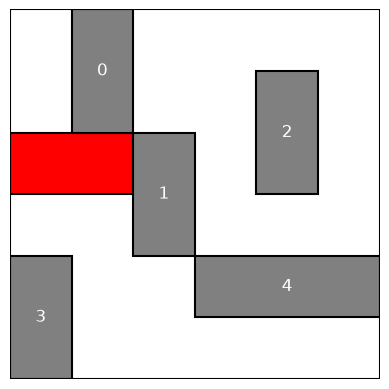

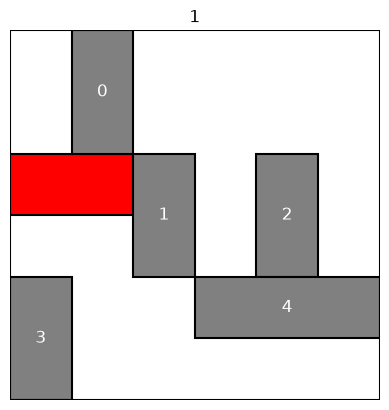

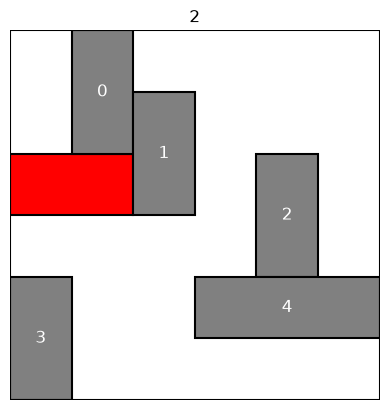

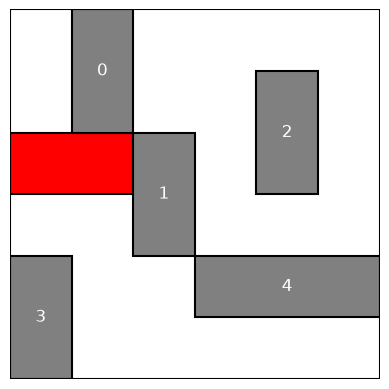

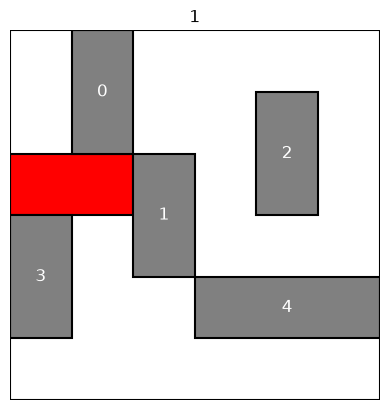

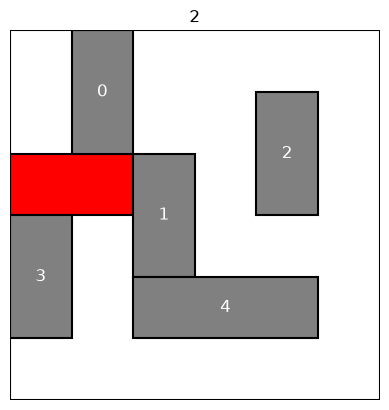

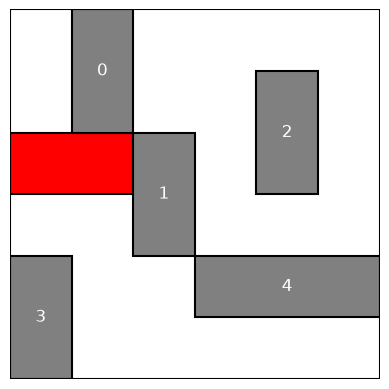

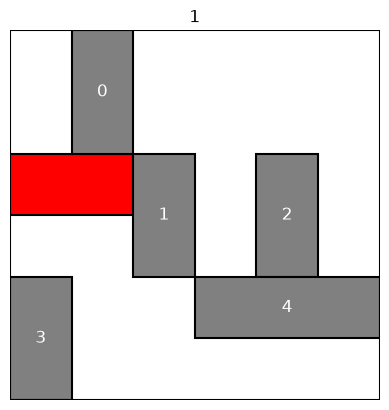

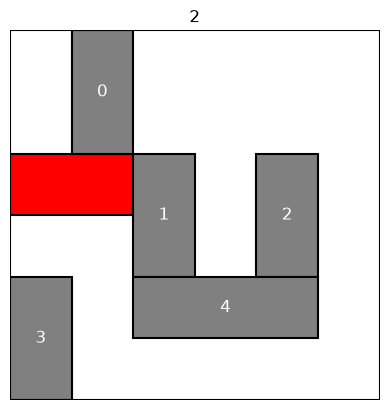

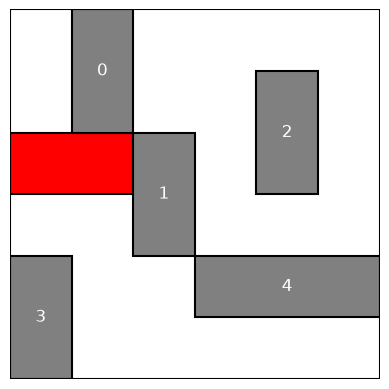

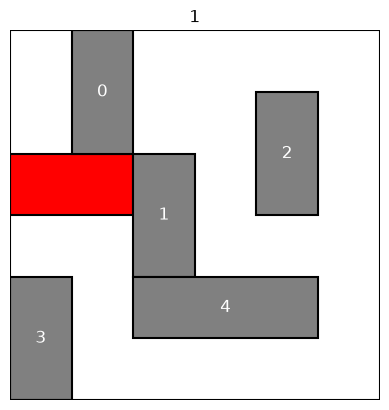

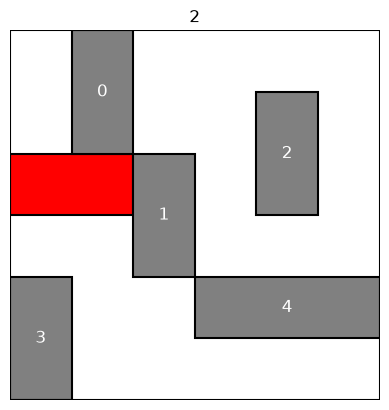

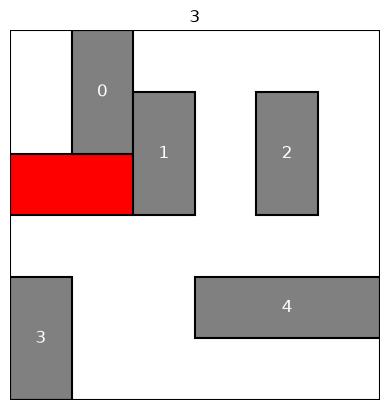

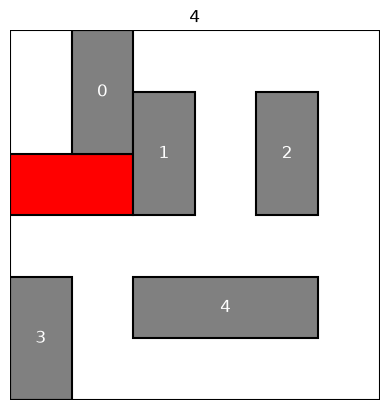

In [94]:
trainer_teach = Train(Agent(puzzle.blocks), puzzle_1)
trainer_teach.learn(200, teach=[0, 10, 20, 50, 100], teach_type="feedback", eval_every=10, decay=0.99)

trainer_no_teach = Train(Agent(puzzle.blocks), puzzle_1)
trainer_no_teach.learn(200, eval_every=10, decay=0.99)

In [95]:
trainer_teach.visualize_evaluation("teach")
trainer_no_teach.visualize_evaluation()

Saved 17 frames to teach/
Saved 23 frames to eval_frames/


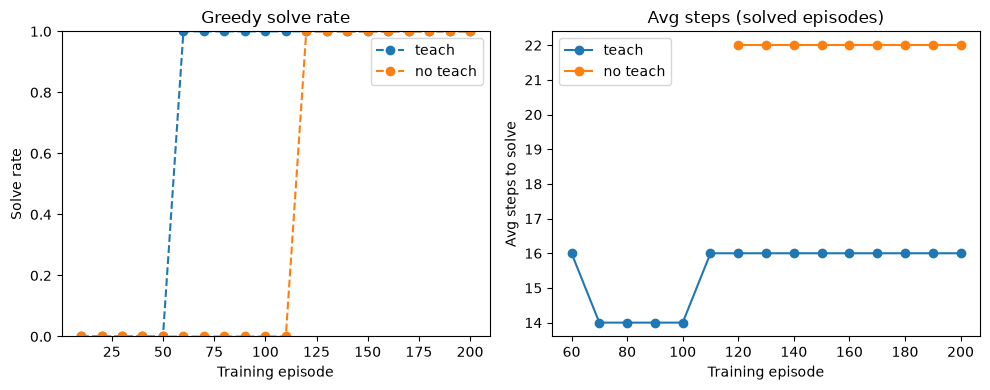

In [96]:
plot_training_results({"teach": trainer_teach.history, "no teach": trainer_no_teach.history})